In [1]:
import gdown
import zipfile
import os

# https://drive.google.com/file/d/1-ko0giZe5ynkAA3EdJCaap7Mrdqr5P55/view?usp=sharing

# Google Drive file ID (Extracted from the URL)
file_id = "1-ko0giZe5ynkAA3EdJCaap7Mrdqr5P55"

# Destination file name
output_zip = "pictures.zip"

# Downloading the file from Google Drive
gdown.download(f"https://drive.google.com/uc?id={file_id}", output_zip, quiet=False)

# Extracting the zip file
with zipfile.ZipFile(output_zip, 'r') as zip_ref:
    zip_ref.extractall("pictures")  # Extracting to 'Clips' folder

# Removing the zip file after extraction
os.remove(output_zip)

print("Download and extraction complete!")


Downloading...
From (original): https://drive.google.com/uc?id=1-ko0giZe5ynkAA3EdJCaap7Mrdqr5P55
From (redirected): https://drive.google.com/uc?id=1-ko0giZe5ynkAA3EdJCaap7Mrdqr5P55&confirm=t&uuid=294323e7-75b5-466c-8945-36c91ad34b95
To: /content/pictures.zip
100%|██████████| 108M/108M [00:02<00:00, 39.8MB/s]


Download and extraction complete!


In [7]:
# CNN + LSTM Pain Expression Classifier (Google Colab-ready)

import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image

# -----------------------------
# CONFIGURATION
# -----------------------------
DATA_ROOT = "/content/pictures"
TRAIN_SUBJECTS = [f"S{str(i).zfill(3)}" for i in range(1, 56)]
TEST_SUBJECTS = [f"S{str(i).zfill(3)}" for i in range(56, 69)]
EXPR_LABELS = {
    'Neutral': 0,
    'Posed Pain': 1,
    'Algometer Pain': 2,
    'Laser Pain': 3
}
IDX_TO_LABEL = {v: k for k, v in EXPR_LABELS.items()}
IMG_SIZE = 224
SEQ_LEN = 20

# -----------------------------
# DATASET CLASS
# -----------------------------
class PainSequenceDataset(Dataset):
    def __init__(self, subject_ids, root_dir, transform=None):
        self.samples = []
        self.transform = transform

        for subject in subject_ids:
            subject_path = os.path.join(root_dir, subject)
            for expr, label in EXPR_LABELS.items():
                expr_path = os.path.join(subject_path, expr, "Colour frames")
                if os.path.exists(expr_path):
                    frame_files = sorted([
                        os.path.join(expr_path, f)
                        for f in os.listdir(expr_path) if f.endswith(".jpg")
                    ])
                    if len(frame_files) == SEQ_LEN:
                        self.samples.append((frame_files, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        frame_paths, label = self.samples[idx]
        frames = [self.transform(Image.open(fp).convert('RGB')) for fp in frame_paths]
        clip_tensor = torch.stack(frames)  # Shape: (SEQ_LEN, 3, H, W)
        return clip_tensor, label

# -----------------------------
# MODEL: CNN + LSTM
# -----------------------------
class CNNLSTM(nn.Module):
    def __init__(self, cnn_output_dim=512, lstm_hidden=256, num_classes=4):
        super(CNNLSTM, self).__init__()
        resnet = models.resnet18(pretrained=True)
        self.cnn = nn.Sequential(*list(resnet.children())[:-1])  # Remove final FC
        self.lstm = nn.LSTM(input_size=cnn_output_dim, hidden_size=lstm_hidden, batch_first=True)
        self.classifier = nn.Linear(lstm_hidden, num_classes)

    def forward(self, x):  # x: (B, T, C, H, W)
        B, T, C, H, W = x.size()
        x = x.view(B * T, C, H, W)
        features = self.cnn(x).squeeze(-1).squeeze(-1)  # Shape: (B*T, 512)
        features = features.view(B, T, -1)  # Shape: (B, T, 512)
        _, (hn, _) = self.lstm(features)
        out = self.classifier(hn[-1])
        return out

# -----------------------------
# TRANSFORMS
# -----------------------------

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.95, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


# -----------------------------
# LOAD DATA
# -----------------------------
train_dataset = PainSequenceDataset(TRAIN_SUBJECTS, DATA_ROOT, transform)
test_dataset = PainSequenceDataset(TEST_SUBJECTS, DATA_ROOT, transform)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, num_workers=2)

# -----------------------------
# TRAINING
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNLSTM().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

EPOCHS = 40
for epoch in range(EPOCHS):
    model.train()
    total_loss, correct = 0, 0
    for clips, labels in train_loader:
        clips, labels = clips.to(device), labels.to(device)
        outputs = model(clips)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * clips.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()

    acc = correct / len(train_dataset)
    print(f"Epoch [{epoch+1}/{EPOCHS}] Loss: {total_loss:.4f} | Accuracy: {acc*100:.2f}%")

# Save the trained model
torch.save(model.state_dict(), "cnn_lstm_pain_model.pth")
print("✅ Model saved to cnn_lstm_pain_model.pth")

# -----------------------------
# EVALUATION
# -----------------------------
model.eval()
correct = 0
with torch.no_grad():
    for clips, labels in test_loader:
        clips, labels = clips.to(device), labels.to(device)
        outputs = model(clips)
        correct += (outputs.argmax(1) == labels).sum().item()

print(f"Test Accuracy: {correct / len(test_dataset) * 100:.2f}%")



/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/40] Loss: 285.9860 | Accuracy: 31.31%
Epoch [2/40] Loss: 214.9244 | Accuracy: 60.28%
Epoch [3/40] Loss: 156.8191 | Accuracy: 71.50%
Epoch [4/40] Loss: 104.4997 | Accuracy: 82.71%
Epoch [5/40] Loss: 64.6609 | Accuracy: 90.65%
Epoch [6/40] Loss: 39.2187 | Accuracy: 93.93%
Epoch [7/40] Loss: 40.2313 | Accuracy: 94.39%
Epoch [8/40] Loss: 40.6787 | Accuracy: 93.46%
Epoch [9/40] Loss: 19.3119 | Accuracy: 96.73%
Epoch [10/40] Loss: 36.7597 | Accuracy: 95.79%
Epoch [11/40] Loss: 16.5662 | Accuracy: 96.73%
Epoch [12/40] Loss: 8.5540 | Accuracy: 99.53%
Epoch [13/40] Loss: 3.7101 | Accuracy: 100.00%
Epoch [14/40] Loss: 2.0665 | Accuracy: 100.00%
Epoch [15/40] Loss: 1.7219 | Accuracy: 100.00%
Epoch [16/40] Loss: 1.3485 | Accuracy: 100.00%
Epoch [17/40] Loss: 1.0767 | Accuracy: 100.00%
Epoch [18/40] Loss: 0.8951 | Accuracy: 100.00%
Epoch [19/40] Loss: 0.7084 | Accuracy: 100.00%
Epoch [20/40] Loss: 0.6544 | Accuracy: 100.00%
Epoch [21/40] Loss: 0.5891 | Accuracy: 100.00%
Epoch [22/40] Loss:

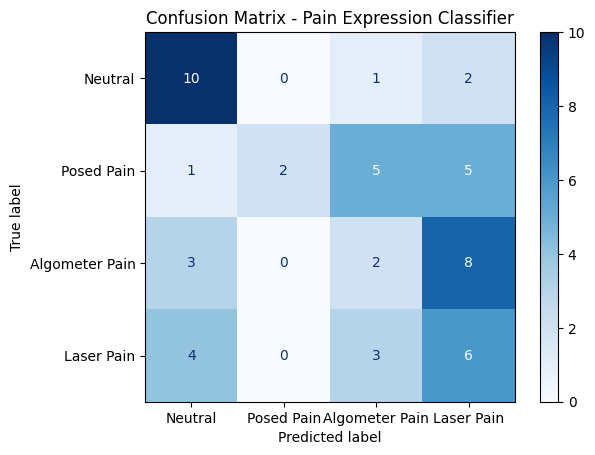

In [13]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(EXPR_LABELS.keys()))
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Pain Expression Classifier")
plt.show()